# SBI tuning for Local Group catalogue inference

This notebook is a separate tuning experiment. It keeps the existing compare notebooks unchanged and focuses on:

- Optuna-based hyperparameter tuning for NPE / SBI
- refitting the best NPE model with full held-out diagnostics
- sampling the tuned posterior for a chosen Local Group target


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import illustris_python as il

candidate_paths = [
    Path.cwd(),
    Path.cwd().parent / "scripts",
    Path.cwd() / "scripts",
    Path.cwd().parent / "illustris_python",
    Path.cwd() / "illustris_python",
]
for p in candidate_paths:
    if p.exists():
        sys.path.insert(0, str(p))

import lg_analogues as lg
from lg_abc import build_pair_catalog
from lg_sbi import infer_with_npe, plot_expected_coverage, plot_sbc_rank_hist, prepare_sbi_problem
from lg_sbi_practical_guide import add_group_m200c_columns, build_observation_vector, plot_1d_posterior_comparison
from lg_sbi_tuning import run_sbi_optuna_study

print("Imports loaded successfully.")


Imports loaded successfully.


## 1) Load the simulation data and rebuild the Local Group pair catalogue


In [2]:
BASE_PATH = os.path.expanduser("~/Documents/uni/dsp/tng300/outputs")
SNAP = 99

SUBHALO_FIELDS = [
    "SubhaloPos",
    "SubhaloVel",
    "SubhaloMass",
    "SubhaloMassType",
    "SubhaloSFRinRad",
    "SubhaloFlag",
    "SubhaloGrNr",
]

sub = il.groupcat.loadSubhalos(BASE_PATH, SNAP, fields=SUBHALO_FIELDS)
halos = il.groupcat.loadHalos(BASE_PATH, SNAP, fields=["Group_M_Crit200"])
header_consts = lg.load_header_constants(BASE_PATH, SNAP)
h = header_consts["h"]
box_ckpch = header_consts["box_ckpch"]

selection_config = lg.SelectionConfig(
    h=h,
    box_ckpch=box_ckpch,
    mstar_min=2e10,
    mstar_max=5e11,
    r_min_kpc=500.0,
    r_max_kpc=1000.0,
    v_tot_max=np.inf,
    vt_min=-np.inf,
    vt_max=np.inf,
    vr_min=-np.inf,
    vr_max=np.inf,
    density_radius_kpc=2000.0,
    intruder_factor=1.0,
    third_massive_factor=1.5,
)

sample = lg.select_central_plus_largest_satellite_by_stellar_mass(
    sub=sub,
    basePath=BASE_PATH,
    snap=SNAP,
    selection_config=selection_config,
)
pair_set = lg.find_pairs_periodic(
    sub=sub,
    sample=sample,
    selection_config=selection_config,
)

pipeline = lg.AnaloguePipeline(pair_set)
iso_mask = lg.isolation_filter_no_third_factor_x_in_same_group(
    sub=sub,
    pairs=pipeline.pairs,
    sample=sample,
    selection_config=selection_config,
)
pipeline.apply_filter(
    f"isolation_x{selection_config.third_massive_factor:g}",
    iso_mask,
)

catalog = build_pair_catalog(
    sample=sample,
    pairs=pipeline.pairs,
    sub=sub,
    sfr_field="SubhaloSFRinRad",
)
catalog = add_group_m200c_columns(
    catalog,
    sample=sample,
    pairs=pipeline.pairs,
    sub=sub,
    halos=halos,
    h=h,
)

pipeline.print_cutflow()
print("Loaded subhalos:", sub["count"])
print("Pairs after cuts:", pipeline.pairs.i.size)


initial: 2655 pairs remaining
isolation_x1.5: 2601 pairs remaining
Loaded subhalos: 14485709
Pairs after cuts: 2601


## 2) Choose the observed system, target, and tuning budget


In [3]:
FEATURE_INFO = {
    "r_kpc": {
        "obs": 770.0,
        "sigma": 15.0,
        "label": "Pair separation r [kpc]",
    },
    "v_r": {
        "obs": -109.0,
        "sigma": 20.0,
        "label": "Radial velocity v_r [km/s]",
    },
    "v_t": {
        "obs": 17.0,
        "sigma": 30.0,
        "label": "Tangential velocity v_t [km/s]",
    },
}

ACTIVE_FEATURES = ["r_kpc", "v_r", "v_t"]
TARGET = "m200c_big"
TARGET_LOG10 = True
LOG10_FEATURES = set()
X_OBS_OVERRIDE = {}
TUNING_TRIALS = 25
POSTERIOR_SAMPLES = 20_000

x_obs = build_observation_vector(FEATURE_INFO, ACTIVE_FEATURES, overrides=X_OBS_OVERRIDE)
sigma = np.array([FEATURE_INFO[name]["sigma"] for name in ACTIVE_FEATURES], dtype=float)

problem = prepare_sbi_problem(
    catalog=catalog,
    features=ACTIVE_FEATURES,
    target=TARGET,
    log10_features=LOG10_FEATURES,
    target_log10=TARGET_LOG10,
)

X = problem["X"]
theta = problem["theta"]
feature_names = problem["feature_names"]
target_name = problem["target_name"]

display(pd.DataFrame({
    "feature": feature_names,
    "x_obs": x_obs,
    "sigma": sigma,
    "label": [FEATURE_INFO[name]["label"] for name in feature_names],
}))
print("Training rows:", X.shape[0])
print("Dropped rows:", problem["dropped_rows"])
print("Target:", target_name, "| target_log10 =", TARGET_LOG10)


,feature,x_obs,sigma,label
0,r_kpc,770.0,15.0,Pair separation r [kpc]
1,v_r,-109.0,20.0,Radial velocity v_r [km/s]
2,v_t,17.0,30.0,Tangential velocity v_t [km/s]


Training rows: 2601
Dropped rows: 0
Target: m200c_big | target_log10 = True


## 3) Run the Optuna-based SBI tuning study


In [4]:
tuning_result = run_sbi_optuna_study(
    X=X,
    theta=theta,
    x_obs=x_obs,
    feature_names=feature_names,
    target_name=target_name,
    n_trials=TUNING_TRIALS,
)
best_fit = tuning_result["best_fit"]
trials_df = tuning_result["trials_df"].sort_values("value", ascending=False, na_position="last")

display(pd.DataFrame([{
    "best_value": tuning_result["best_value"],
    **tuning_result["best_params"],
}]))
display(trials_df)


[I 2026-03-31 22:53:48,409] A new study created in memory with name: no-name-fdd93341-cbef-41cd-a6a7-162f36d898bd


 Neural network successfully converged after 155 epochs.

[I 2026-03-31 22:55:20,714] Trial 0 finished with value: -0.35247626243493496 and parameters: {'density_model': 'nsf', 'hidden_features': 32, 'num_transforms': 6, 'training_batch_size': 256, 'learning_rate': 0.00044818326788762826, 'validation_fraction': 0.1687587557123997, 'stop_after_epochs': 50}. Best is trial 0 with value: -0.35247626243493496.


 Neural network successfully converged after 56 epochs.

[I 2026-03-31 22:57:38,095] Trial 1 finished with value: -0.3298652244684024 and parameters: {'density_model': 'nsf', 'hidden_features': 64, 'num_transforms': 8, 'training_batch_size': 64, 'learning_rate': 0.0021188277784090774, 'validation_fraction': 0.06774116388033999, 'stop_after_epochs': 50}. Best is trial 1 with value: -0.3298652244684024.
/home/tp/Documents/uni/dsp/.venv/lib/python3.12/site-packages/sbi/neural_nets/net_builders/flow.py:149: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


...

 Neural network successfully converged after 42 epochs.

[I 2026-03-31 23:21:17,638] Trial 24 finished with value: -0.2834410907366337 and parameters: {'density_model': 'nsf', 'hidden_features': 64, 'num_transforms': 4, 'training_batch_size': 128, 'learning_rate': 0.0016561530555891674, 'validation_fraction': 0.17485125295591325, 'stop_after_epochs': 30}. Best is trial 24 with value: -0.2834410907366337.


 Neural network successfully converged after 51 epochs.

,best_value,density_model,hidden_features,num_transforms,training_batch_size,learning_rate,validation_fraction,stop_after_epochs
0,-0.283441,nsf,64,4,128,0.001656,0.174851,30


,number,state,value,param_density_model,param_hidden_features,param_num_transforms,param_training_batch_size,param_learning_rate,param_validation_fraction,param_stop_after_epochs,user_train_size,user_calibration_size
24,24,COMPLETE,-0.283441,nsf,64,4,128,0.001656,0.174851,30,2211,390
12,12,COMPLETE,-0.303263,nsf,64,5,64,0.003520,0.122042,50,2211,390
18,18,COMPLETE,-0.304065,nsf,64,5,64,0.002781,0.152412,50,2211,390
23,23,COMPLETE,-0.312643,nsf,64,4,128,0.002995,0.179837,30,2211,390
20,20,COMPLETE,-0.321003,nsf,64,5,128,0.002700,0.156272,30,2211,390
14,14,COMPLETE,-0.323671,nsf,64,7,64,0.004575,0.108129,50,2211,390
15,15,COMPLETE,-0.325461,nsf,64,7,64,0.004175,0.115300,50,2211,390
1,1,COMPLETE,-0.329865,nsf,64,8,64,0.002119,0.067741,50,2211,390
21,21,COMPLETE,-0.331760,nsf,64,5,128,0.002922,0.157609,30,2211,390
22,22,COMPLETE,-0.336741,nsf,64,5,128,0.001552,0.138921,30,2211,390


## 4) Draw samples from the best-tuned posterior


,method,mean,median,q16,q84
0,Best tuned SBI,12.326542,12.243467,12.110562,12.503281


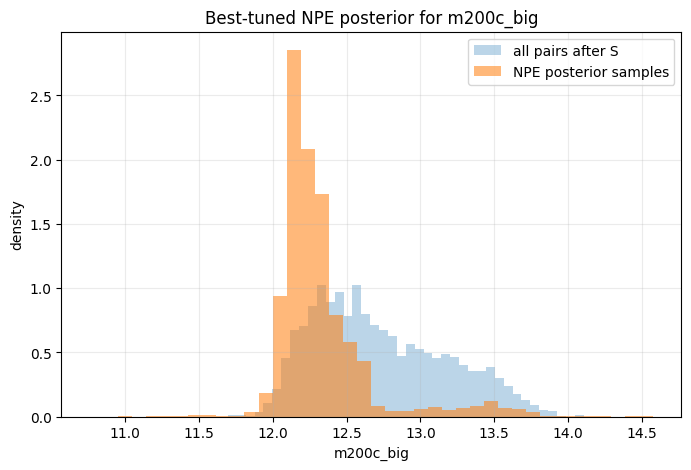

In [5]:
sbi_result = infer_with_npe(
    best_fit,
    x_obs=x_obs,
    num_samples=POSTERIOR_SAMPLES,
    random_state=0,
)

display(pd.DataFrame([{"method": "Best tuned SBI", **sbi_result["summary"]}]))
fig, ax = plot_1d_posterior_comparison(
    theta,
    sbi_result["samples"],
    target_name=target_name,
    title=f"Best-tuned NPE posterior for {target_name}",
)
plt.show()


## 5) Tuned SBI diagnostic summary


,train_size,calibration_size,mean_calibration_log_prob
0,2211,390,-0.307193


,feature,x_obs,train_min,train_max,outside_range
0,r_kpc,770.0,500.371246,999.99115,False
1,v_r,-109.0,-1282.880737,748.37384,False
2,v_t,17.0,3.006503,1626.08020,False


Nearest standardized distance: 0.04018945501151344


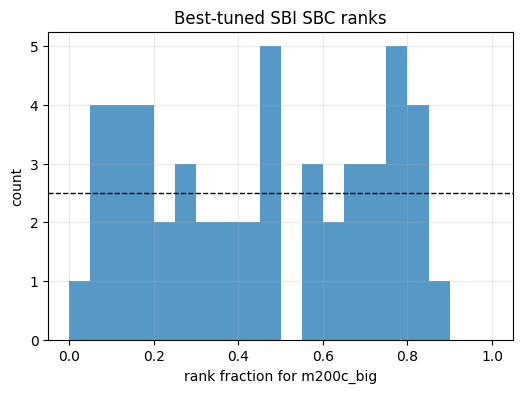

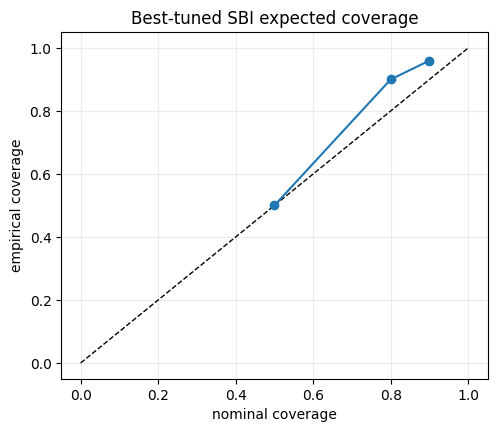

In [6]:
diag = best_fit["diagnostics"]
display(pd.DataFrame([{
    "train_size": diag["train_size"],
    "calibration_size": diag["calibration_size"],
    "mean_calibration_log_prob": diag["mean_calibration_log_prob"],
}]))

support = diag.get("x_obs_support_check", {})
if support:
    display(pd.DataFrame({
        "feature": feature_names,
        "x_obs": x_obs,
        "train_min": support["feature_min"],
        "train_max": support["feature_max"],
        "outside_range": support["outside_range"],
    }))
    print("Nearest standardized distance:", support["nearest_distance"])

if diag["sbc_ranks"].size > 0:
    plot_sbc_rank_hist(
        diag["sbc_ranks"],
        num_posterior_samples=diag["sbc_summary"]["num_posterior_samples"],
        parameter_label=target_name,
        title="Best-tuned SBI SBC ranks",
    )
    plt.show()

coverage_result = diag.get("expected_coverage_1d", {})
if len(np.asarray(coverage_result.get("levels", []))) > 0:
    plot_expected_coverage(coverage_result, title="Best-tuned SBI expected coverage")
    plt.show()
